# Beam Search from Scratch — Solution

Build order:
1. **Stage 1** — Greedy decoding baseline (single hypothesis)
2. **Stage 2** — Beam search core: maintaining k hypotheses
3. **Stage 3** — Log-probability scoring & length normalization
4. **Stage 4** — Full beam search with early stopping
5. **Stage 5** — Comparison & analysis

## Setup

In [1]:
!pip install transformers torch matplotlib numpy --quiet


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass, field
from typing import Optional
from transformers import AutoTokenizer, AutoModelForCausalLM

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
MODEL_NAME = "gpt2"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device).eval()

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocab size:   {tokenizer.vocab_size:,}")

Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model params: 124,439,808
Vocab size:   50,257


---
## Stage 1 — Greedy Decoding Baseline

Greedy decoding picks the single most likely token at each step:

$$x_t = \arg\max_{v} P(v \mid x_{<t})$$

This is a special case of beam search with beam width $k=1$. It's fast but **locally optimal** — it can miss globally better sequences because it never considers alternatives.

```
Step 1:  "The" → pick best → "cat"
Step 2:  "The cat" → pick best → "sat"
Step 3:  "The cat sat" → pick best → "on"
...never reconsiders "The dog" even if it leads to a higher-probability sequence
```

In [4]:
def greedy_decode(
    model,
    input_ids: torch.Tensor,
    max_new_tokens: int = 50,
) -> tuple[torch.Tensor, float]:
    """
    Greedy autoregressive decoding with KV cache.

    Args:
        model:          causal LM
        input_ids:      [1, seq_len] prompt token ids
        max_new_tokens: maximum tokens to generate

    Returns:
        (output_ids, total_log_prob):
          output_ids:     [1, seq_len + n_generated] full sequence
          total_log_prob: sum of log-probabilities of chosen tokens
    """
    generated = input_ids.clone()
    past_key_values = None
    total_log_prob = 0.0

    with torch.no_grad():
        for _ in range(max_new_tokens):
            model_input = generated if past_key_values is None else generated[:, -1:]
            outputs = model(
                model_input,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values

            logits = outputs.logits[:, -1, :]  # [1, vocab]
            log_probs = F.log_softmax(logits, dim=-1)

            next_token = logits.argmax(dim=-1, keepdim=True)  # [1, 1]
            total_log_prob += log_probs[0, next_token[0, 0]].item()

            generated = torch.cat([generated, next_token], dim=-1)

            if next_token.item() == tokenizer.eos_token_id:
                break

    return generated, total_log_prob

In [5]:
# --- Sanity check ---
prompt = "The capital of France is"
input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

output_ids, log_prob = greedy_decode(model, input_ids, max_new_tokens=30)
text = tokenizer.decode(output_ids[0])
n_generated = output_ids.shape[1] - input_ids.shape[1]

print(f"Prompt:     {prompt!r}")
print(f"Generated:  {text!r}")
print(f"Tokens generated: {n_generated}")
print(f"Total log-prob:   {log_prob:.4f}")
print(f"Avg log-prob/token: {log_prob / n_generated:.4f}")

Prompt:     'The capital of France is'
Generated:  'The capital of France is the capital of the French Republic, and the capital of the French Republic is the capital of the French Republic.\n\nThe French Republic is the capital'
Tokens generated: 30
Total log-prob:   -33.7533
Avg log-prob/token: -1.1251


---
## Stage 2 — Beam Search Core: Maintaining k Hypotheses

Beam search is a **breadth-first search** with a fixed-width frontier. At each step, instead of keeping only the single best token (greedy), we maintain the **top-k partial sequences** ("beams" or "hypotheses").

The dynamic programming insight:
- **State:** a partial sequence $x_{1:t}$ and its cumulative score
- **Transition:** extend each beam by every possible next token
- **Pruning:** keep only the top-k scoring extensions

```
Step 0: ["The"]                                          (1 beam)
Step 1: ["The cat", "The dog", "The old"]                 (k=3 beams)
Step 2: ["The cat sat", "The dog ran", "The old man"]      (k=3 beams)
...at each step, we expand all k beams by vocab_size candidates,
   then keep only the top k by cumulative score.
```

The score of a sequence is typically the **sum of log-probabilities** of each token:

$$\text{score}(x_{1:t}) = \sum_{i=1}^{t} \log P(x_i \mid x_{<i})$$

### 2a — Hypothesis data structure

In [6]:
@dataclass
class Hypothesis:
    """A single beam hypothesis."""
    token_ids: list[int]   # full token sequence (prompt + generated)
    log_prob: float        # cumulative log-probability of generated tokens
    n_generated: int = 0   # number of tokens generated (excludes prompt)
    is_finished: bool = False

    @property
    def avg_log_prob(self) -> float:
        """Average log-prob per generated token."""
        if self.n_generated == 0:
            return 0.0
        return self.log_prob / self.n_generated

    def length_normalized_score(self, alpha: float = 0.6) -> float:
        """
        Length-normalized score (Wu et al., 2016).
        lp(y) = ((5 + |y|) / 6)^alpha
        score = log_prob / lp(y)
        """
        length_penalty = ((5 + self.n_generated) / 6) ** alpha
        return self.log_prob / length_penalty

In [7]:
# --- Sanity check ---
h = Hypothesis(token_ids=[1, 2, 3, 4, 5], log_prob=-5.0, n_generated=3)
print(f"Token IDs:      {h.token_ids}")
print(f"Log-prob:       {h.log_prob:.4f}")
print(f"Avg log-prob:   {h.avg_log_prob:.4f}")
print(f"Length-norm (α=0.6): {h.length_normalized_score(0.6):.4f}")
print(f"Length-norm (α=0.0): {h.length_normalized_score(0.0):.4f}  (= raw log-prob)")

Token IDs:      [1, 2, 3, 4, 5]
Log-prob:       -5.0000
Avg log-prob:   -1.6667
Length-norm (α=0.6): -4.2073
Length-norm (α=0.0): -5.0000  (= raw log-prob)


### 2b — Single expansion step

The core operation: given k active hypotheses, expand each by every possible next token, producing up to k × vocab_size candidates, then keep only the top-k.

In [8]:
def beam_step(
    model,
    hypotheses: list[Hypothesis],
    beam_width: int,
    eos_token_id: int,
) -> tuple[list[Hypothesis], list[Hypothesis]]:
    """
    Perform one step of beam search expansion.

    For each active hypothesis:
      1. Run model forward pass to get next-token log-probs
      2. Score all possible extensions: parent_score + log_prob(token)
      3. Collect all candidates from all beams
    Then keep top beam_width candidates as the new active set.

    Args:
        model:        causal LM
        hypotheses:   list of active (non-finished) Hypothesis objects
        beam_width:   k — number of beams to maintain
        eos_token_id: end-of-sequence token id

    Returns:
        (active, finished):
          active:   list of top-k non-finished hypotheses for next step
          finished: list of hypotheses that hit EOS this step
    """
    all_candidates = []

    for hyp in hypotheses:
        if hyp.is_finished:
            continue

        input_tensor = torch.tensor([hyp.token_ids], device=device)

        with torch.no_grad():
            outputs = model(input_tensor, use_cache=False)

        logits = outputs.logits[0, -1, :]  # [vocab]
        log_probs = F.log_softmax(logits, dim=-1)

        # Get top beam_width candidates from this hypothesis
        # (optimization: no need to consider all vocab_size tokens)
        top_log_probs, top_indices = log_probs.topk(beam_width * 2)

        for lp, idx in zip(top_log_probs.tolist(), top_indices.tolist()):
            new_hyp = Hypothesis(
                token_ids=hyp.token_ids + [idx],
                log_prob=hyp.log_prob + lp,
                n_generated=hyp.n_generated + 1,
                is_finished=(idx == eos_token_id),
            )
            all_candidates.append(new_hyp)

    # Sort all candidates by score (descending) and keep top beam_width
    all_candidates.sort(key=lambda h: h.log_prob, reverse=True)

    active = []
    finished = []
    for hyp in all_candidates:
        if len(active) >= beam_width and not hyp.is_finished:
            continue
        if hyp.is_finished:
            finished.append(hyp)
        else:
            active.append(hyp)
        if len(active) >= beam_width:
            break

    return active, finished

In [9]:
# --- Sanity check: one beam step ---
prompt_ids = tokenizer.encode(prompt)
initial_hyp = [Hypothesis(token_ids=prompt_ids, log_prob=0.0, n_generated=0)]

active, finished = beam_step(model, initial_hyp, beam_width=3, eos_token_id=tokenizer.eos_token_id)

print(f"After 1 step with beam_width=3:")
print(f"  Active beams: {len(active)}, Finished: {len(finished)}")
for i, h in enumerate(active):
    text = tokenizer.decode(h.token_ids)
    print(f"  Beam {i}: score={h.log_prob:.4f}  text={text!r}")

After 1 step with beam_width=3:
  Active beams: 3, Finished: 0
  Beam 0: score=-2.4699  text='The capital of France is the'
  Beam 1: score=-3.0377  text='The capital of France is now'
  Beam 2: score=-3.0757  text='The capital of France is a'


### 2c — Visualize the beam search tree

Let's run a few steps and visualize how the beams evolve.

In [10]:
def trace_beam_steps(
    model,
    prompt_ids: list[int],
    beam_width: int,
    n_steps: int,
    eos_token_id: int,
) -> list[list[Hypothesis]]:
    """Run beam search for n_steps, returning the active beams at each step."""
    active = [Hypothesis(token_ids=prompt_ids, log_prob=0.0, n_generated=0)]
    history = [list(active)]

    for _ in range(n_steps):
        active, finished = beam_step(model, active, beam_width, eos_token_id)
        history.append(list(active))
        if not active:
            break

    return history

In [11]:
beam_width = 4
n_steps = 6
history = trace_beam_steps(model, prompt_ids, beam_width, n_steps, tokenizer.eos_token_id)

print(f"Beam search trace: beam_width={beam_width}, prompt={prompt!r}\n")
print(f"{'Step':<6s} {'Beam':<6s} {'Score':>8s}  {'Generated text'}")
print("-" * 80)

for step, beams in enumerate(history):
    for b, hyp in enumerate(beams):
        generated_text = tokenizer.decode(hyp.token_ids[len(prompt_ids):])
        print(f"{step:<6d} {b:<6d} {hyp.log_prob:>8.3f}  {generated_text!r}")
    print()

Beam search trace: beam_width=4, prompt='The capital of France is'

Step   Beam      Score  Generated text
--------------------------------------------------------------------------------
0      0         0.000  ''

1      0        -2.470  ' the'
1      1        -3.038  ' now'
1      2        -3.076  ' a'
1      3        -3.430  ' France'

2      0        -4.244  ' the capital'
2      1        -4.417  ' France,'
2      2        -4.644  ' France.'
2      3        -5.301  ' now home'

3      0        -4.319  ' the capital of'
3      1        -5.306  ' now home to'
3      2        -5.751  ' France, and'
3      3        -6.748  ' France. The'

4      0        -5.583  ' the capital of the'
4      1        -5.915  ' the capital of France'
4      2        -7.172  ' the capital of a'
4      3        -7.302  ' now home to the'

5      0        -6.945  ' the capital of France,'
5      1        -7.155  ' the capital of France.'
5      2        -7.573  ' the capital of the French'
5      3        

---
## Stage 3 — Log-Probability Scoring & Length Normalization

### The length bias problem

Raw log-probability scoring has a fundamental problem: **longer sequences always have lower (more negative) scores** because each additional token multiplies the probability (adds a negative log-prob).

This creates a bias toward shorter outputs. There are several ways to fix this:

**1. Average log-probability:**
$$\text{score}(y) = \frac{1}{|y|} \sum_{t=1}^{|y|} \log P(y_t \mid y_{<t})$$

**2. Length penalty (Wu et al., 2016 — Google NMT):**
$$\text{score}(y) = \frac{\log P(y)}{\text{lp}(y)}, \quad \text{lp}(y) = \frac{(5 + |y|)^\alpha}{6^\alpha}$$

where $\alpha \in [0, 1]$ controls the strength. $\alpha = 0$ gives raw log-prob; $\alpha = 1$ is close to averaging.

In [12]:
def length_penalty(length: int, alpha: float = 0.6) -> float:
    """
    Length penalty from Wu et al. (2016).
    lp(y) = ((5 + |y|) / 6)^alpha
    """
    return ((5 + length) / 6) ** alpha


def score_hypothesis(hyp: Hypothesis, alpha: float = 0.6) -> float:
    """
    Score a hypothesis with length normalization.

    Args:
        hyp:   a Hypothesis object
        alpha: length penalty exponent (0 = no penalty, 1 = strong penalty)

    Returns:
        length-normalized score
    """
    if hyp.n_generated == 0:
        return 0.0
    lp = length_penalty(hyp.n_generated, alpha)
    return hyp.log_prob / lp

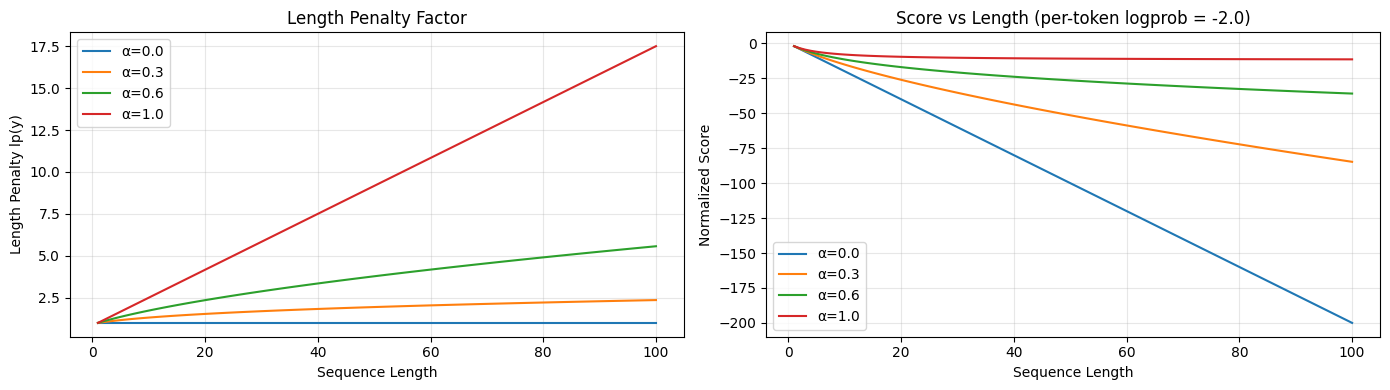

In [13]:
# --- Visualize length penalty behavior ---
lengths = list(range(1, 101))
alphas = [0.0, 0.3, 0.6, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Length penalty values
for alpha in alphas:
    penalties = [length_penalty(l, alpha) for l in lengths]
    axes[0].plot(lengths, penalties, label=f"α={alpha}")
axes[0].set_xlabel("Sequence Length")
axes[0].set_ylabel("Length Penalty lp(y)")
axes[0].set_title("Length Penalty Factor")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Effect on scoring
# Simulate: constant per-token log-prob of -2.0
per_token_lp = -2.0
for alpha in alphas:
    scores = []
    for l in lengths:
        raw_lp = per_token_lp * l
        lp = length_penalty(l, alpha)
        scores.append(raw_lp / lp)
    axes[1].plot(lengths, scores, label=f"α={alpha}")
axes[1].set_xlabel("Sequence Length")
axes[1].set_ylabel("Normalized Score")
axes[1].set_title("Score vs Length (per-token logprob = -2.0)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Stage 4 — Full Beam Search with Early Stopping

Putting it all together: the full beam search loop with:
- k active hypotheses maintained at each step
- Finished hypotheses collected when they hit EOS
- Length-normalized scoring for final ranking
- Early stopping when all beams are finished or a max length is reached

**Key optimization insight:** We don't need KV caches here because we recompute from scratch each step (simpler but slower). A production implementation would batch all beams together and use KV caches — but the algorithmic structure is the same.

In [14]:
@dataclass
class BeamSearchResult:
    """Container for beam search outputs."""
    hypotheses: list[Hypothesis]
    best_text: str
    best_score: float
    wall_time: float
    n_model_calls: int

In [15]:
def beam_search(
    model,
    tokenizer,
    prompt: str,
    beam_width: int = 5,
    max_new_tokens: int = 50,
    length_penalty_alpha: float = 0.6,
    n_best: int = 1,
) -> BeamSearchResult:
    """
    Full beam search decoding.

    Algorithm:
      1. Start with a single hypothesis (the prompt)
      2. At each step:
         a. For each active beam, run model to get next-token log-probs
         b. Expand each beam by top candidates
         c. Collect all candidates, keep top beam_width by score
         d. Move finished beams (hit EOS) to finished list
      3. Repeat until all beams are finished or max_new_tokens reached
      4. Rank all finished hypotheses by length-normalized score

    Args:
        model:                causal LM
        tokenizer:            tokenizer
        prompt:               input text
        beam_width:           number of beams (k)
        max_new_tokens:       maximum generation length
        length_penalty_alpha: α for length normalization (0=none, 1=strong)
        n_best:               how many top hypotheses to return

    Returns:
        BeamSearchResult with top-n hypotheses
    """
    t0 = time.time()
    prompt_ids = tokenizer.encode(prompt)
    eos_id = tokenizer.eos_token_id

    active = [Hypothesis(token_ids=prompt_ids, log_prob=0.0, n_generated=0)]
    finished = []
    n_model_calls = 0

    for step in range(max_new_tokens):
        if not active:
            break

        all_candidates = []

        for hyp in active:
            input_tensor = torch.tensor([hyp.token_ids], device=device)
            with torch.no_grad():
                outputs = model(input_tensor, use_cache=False)
            n_model_calls += 1

            logits = outputs.logits[0, -1, :]
            log_probs = F.log_softmax(logits, dim=-1)

            # Consider top 2*beam_width tokens per beam
            top_lps, top_ids = log_probs.topk(beam_width * 2)

            for lp, tid in zip(top_lps.tolist(), top_ids.tolist()):
                new_hyp = Hypothesis(
                    token_ids=hyp.token_ids + [tid],
                    log_prob=hyp.log_prob + lp,
                    n_generated=hyp.n_generated + 1,
                    is_finished=(tid == eos_id),
                )
                all_candidates.append(new_hyp)

        # Separate finished and active
        all_candidates.sort(key=lambda h: h.log_prob, reverse=True)

        new_active = []
        for hyp in all_candidates:
            if hyp.is_finished:
                finished.append(hyp)
            else:
                if len(new_active) < beam_width:
                    new_active.append(hyp)

        active = new_active

        # Early stopping: if the best finished hypothesis scores higher
        # than any possible extension of active beams
        if finished and active:
            best_finished_score = max(
                score_hypothesis(h, length_penalty_alpha) for h in finished
            )
            # The best active beam can only get worse (log-probs are negative)
            best_active_score = score_hypothesis(active[0], length_penalty_alpha)
            if best_finished_score >= best_active_score:
                break

    # Add any remaining active hypotheses to finished
    finished.extend(active)

    # Rank by length-normalized score
    finished.sort(
        key=lambda h: score_hypothesis(h, length_penalty_alpha),
        reverse=True,
    )

    top_n = finished[:n_best]
    best = top_n[0] if top_n else active[0]

    return BeamSearchResult(
        hypotheses=top_n,
        best_text=tokenizer.decode(best.token_ids),
        best_score=score_hypothesis(best, length_penalty_alpha),
        wall_time=time.time() - t0,
        n_model_calls=n_model_calls,
    )

In [16]:
# --- Sanity check ---
result = beam_search(
    model, tokenizer, prompt,
    beam_width=5, max_new_tokens=30, length_penalty_alpha=0.6, n_best=5,
)

print(f'Prompt: "{prompt}"\n')
print(f"Best: {result.best_text!r}")
print(f"Score: {result.best_score:.4f}")
print(f"Time: {result.wall_time:.2f}s, Model calls: {result.n_model_calls}")
print(f"\nTop-{len(result.hypotheses)} hypotheses:")
for i, hyp in enumerate(result.hypotheses):
    text = tokenizer.decode(hyp.token_ids[len(tokenizer.encode(prompt)):])
    score = score_hypothesis(hyp, 0.6)
    print(f"  {i+1}. score={score:>7.3f}  logp={hyp.log_prob:>8.3f}  len={hyp.n_generated:>3d}  text={text!r}")

Prompt: "The capital of France is"

Best: 'The capital of France is the capital of France. It is the capital of France. It is the capital of France. It is the capital of France. It is the capital'
Score: -6.3102
Time: 1.51s, Model calls: 146

Top-5 hypotheses:
  1. score= -6.310  logp= -18.180  len= 30  text=' the capital of France. It is the capital of France. It is the capital of France. It is the capital of France. It is the capital'
  2. score= -7.378  logp= -21.257  len= 30  text=' the capital of France, and the capital of France is the capital of France, and the capital of France is the capital of France, and the capital'
  3. score= -8.270  logp= -23.828  len= 30  text=' the capital of France. It is the capital of France. It is the capital of France. It is the capital of France.\n\nIt is'
  4. score= -8.278  logp= -23.849  len= 30  text=' the capital of France, and the capital of France is the capital of France, and the capital of France is the capital of France.\n\nThe'
  5. sc

### 4b — Effect of beam width

In [17]:
beam_widths = [1, 2, 3, 5, 10]
test_prompt = "The future of artificial intelligence is"

print(f'Prompt: "{test_prompt}"')
print("=" * 100)

bw_results = []
for bw in beam_widths:
    r = beam_search(
        model, tokenizer, test_prompt,
        beam_width=bw, max_new_tokens=30, length_penalty_alpha=0.6,
    )
    bw_results.append(r)
    generated = r.best_text[len(test_prompt):]
    print(f"\n[k={bw:>2d}]  score={r.best_score:>7.3f}  time={r.wall_time:.1f}s  calls={r.n_model_calls}")
    print(f"  {r.best_text}")

Prompt: "The future of artificial intelligence is"

[k= 1]  score=-16.996  time=0.3s  calls=30
  The future of artificial intelligence is uncertain.

"We're not sure what the future will look like," said Dr. Michael S. Schoenfeld, a professor of computer

[k= 2]  score=-11.878  time=0.5s  calls=49
  The future of artificial intelligence is uncertain, but it's clear that it's going to change the way we think about the world.<|endoftext|>

[k= 3]  score=-13.290  time=0.9s  calls=88
  The future of artificial intelligence is in the hands of the next generation of researchers.

"We're going to see a lot of advances in artificial intelligence in the next few years

[k= 5]  score= -9.323  time=0.7s  calls=71
  The future of artificial intelligence is in the hands of the next generation.<|endoftext|>

[k=10]  score= -9.323  time=1.4s  calls=141
  The future of artificial intelligence is in the hands of the next generation.<|endoftext|>


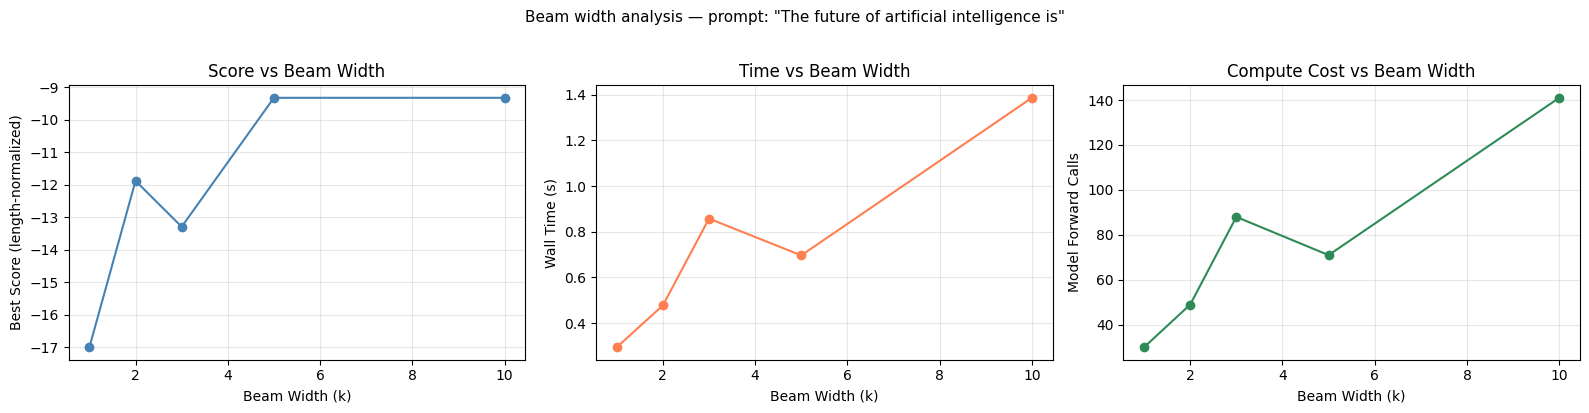

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

scores = [r.best_score for r in bw_results]
times = [r.wall_time for r in bw_results]
calls = [r.n_model_calls for r in bw_results]

axes[0].plot(beam_widths, scores, "o-", color="steelblue")
axes[0].set_xlabel("Beam Width (k)")
axes[0].set_ylabel("Best Score (length-normalized)")
axes[0].set_title("Score vs Beam Width")
axes[0].grid(True, alpha=0.3)

axes[1].plot(beam_widths, times, "o-", color="coral")
axes[1].set_xlabel("Beam Width (k)")
axes[1].set_ylabel("Wall Time (s)")
axes[1].set_title("Time vs Beam Width")
axes[1].grid(True, alpha=0.3)

axes[2].plot(beam_widths, calls, "o-", color="seagreen")
axes[2].set_xlabel("Beam Width (k)")
axes[2].set_ylabel("Model Forward Calls")
axes[2].set_title("Compute Cost vs Beam Width")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Beam width analysis — prompt: "{test_prompt}"', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### 4c — Effect of length penalty

In [19]:
alphas = [0.0, 0.3, 0.6, 1.0, 1.5]

print(f'Prompt: "{test_prompt}"')
print("=" * 100)

alpha_results = []
for alpha in alphas:
    r = beam_search(
        model, tokenizer, test_prompt,
        beam_width=5, max_new_tokens=40, length_penalty_alpha=alpha,
    )
    alpha_results.append(r)
    best_hyp = r.hypotheses[0]
    print(f"\n[α={alpha:.1f}]  len={best_hyp.n_generated}  raw_logp={best_hyp.log_prob:.3f}  norm_score={r.best_score:.3f}")
    print(f"  {r.best_text}")

Prompt: "The future of artificial intelligence is"

[α=0.0]  len=9  raw_logp=-15.500  norm_score=-15.500
  The future of artificial intelligence is in the hands of the next generation.<|endoftext|>

[α=0.3]  len=9  raw_logp=-15.500  norm_score=-12.021
  The future of artificial intelligence is in the hands of the next generation.<|endoftext|>

[α=0.6]  len=9  raw_logp=-15.500  norm_score=-9.323
  The future of artificial intelligence is in the hands of the next generation.<|endoftext|>

[α=1.0]  len=40  raw_logp=-28.617  norm_score=-3.816
  The future of artificial intelligence is in the hands of the next generation of scientists and engineers.

The future of artificial intelligence is in the hands of the next generation of scientists and engineers.

The future of artificial intelligence is

[α=1.5]  len=40  raw_logp=-28.617  norm_score=-1.393
  The future of artificial intelligence is in the hands of the next generation of scientists and engineers.

The future of artificial intelligen

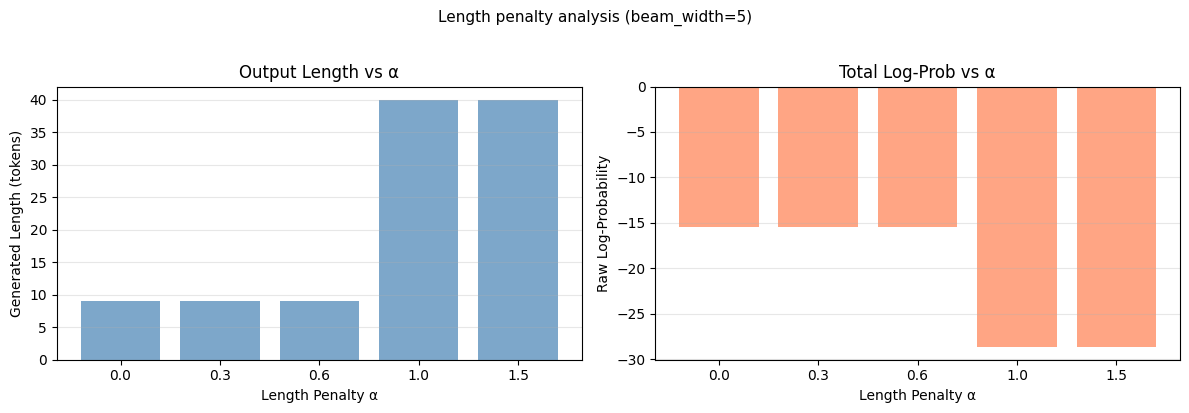

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gen_lengths = [r.hypotheses[0].n_generated for r in alpha_results]
norm_scores = [r.best_score for r in alpha_results]

axes[0].bar([str(a) for a in alphas], gen_lengths, color="steelblue", alpha=0.7)
axes[0].set_xlabel("Length Penalty α")
axes[0].set_ylabel("Generated Length (tokens)")
axes[0].set_title("Output Length vs α")
axes[0].grid(True, alpha=0.3, axis="y")

raw_logprobs = [r.hypotheses[0].log_prob for r in alpha_results]
axes[1].bar([str(a) for a in alphas], raw_logprobs, color="coral", alpha=0.7)
axes[1].set_xlabel("Length Penalty α")
axes[1].set_ylabel("Raw Log-Probability")
axes[1].set_title("Total Log-Prob vs α")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle(f'Length penalty analysis (beam_width=5)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

---
## Stage 5 — Comparison & Analysis

Compare greedy decoding vs beam search across multiple prompts.

In [21]:
comparison_prompts = [
    "The capital of France is",
    "In a surprising turn of events,",
    "The best way to learn programming is",
    "Once upon a time, there was a",
]

print(f"{'Method':<12s} | {'Prompt':<40s} | {'Score':>8s} | {'Len':>4s} | Generated text")
print("-" * 130)

for p in comparison_prompts:
    p_ids = tokenizer.encode(p, return_tensors="pt").to(device)

    # Greedy
    g_out, g_logp = greedy_decode(model, p_ids, max_new_tokens=30)
    g_text = tokenizer.decode(g_out[0])
    g_ngen = g_out.shape[1] - p_ids.shape[1]
    g_score = g_logp / length_penalty(g_ngen, 0.6) if g_ngen > 0 else 0

    # Beam search (k=5)
    b_result = beam_search(model, tokenizer, p, beam_width=5, max_new_tokens=30, length_penalty_alpha=0.6)
    b_hyp = b_result.hypotheses[0]
    b_gen = tokenizer.decode(b_hyp.token_ids[len(tokenizer.encode(p)):])

    print(f"{'Greedy':<12s} | {p:<40s} | {g_score:>8.3f} | {g_ngen:>4d} | {g_text[len(p):]!r}")
    print(f"{'Beam k=5':<12s} | {'':<40s} | {b_result.best_score:>8.3f} | {b_hyp.n_generated:>4d} | {b_gen!r}")
    print()

Method       | Prompt                                   |    Score |  Len | Generated text
----------------------------------------------------------------------------------------------------------------------------------
Greedy       | The capital of France is                 |  -11.716 |   30 | ' the capital of the French Republic, and the capital of the French Republic is the capital of the French Republic.\n\nThe French Republic is the capital'
Beam k=5     |                                          |   -6.310 |   30 | ' the capital of France. It is the capital of France. It is the capital of France. It is the capital of France. It is the capital'

Greedy       | In a surprising turn of events,          |  -18.501 |   30 | ' the government has now announced that it will not be able to pay for the cost of the new school.\n\nThe government has also announced that it'
Beam k=5     |                                          |  -14.430 |   30 | ' it turns out that there is no such thing

### 5b — When does beam search help (and hurt)?

Beam search is most useful for **structured outputs** where global coherence matters (e.g., translation, summarization). For open-ended generation, it can produce **repetitive, degenerate text** — a known failure mode where high-probability sequences end up being boring loops.

Let's demonstrate this with a longer generation.

In [22]:
long_prompt = "The meaning of life is"
max_tokens = 60

# Greedy
g_ids = tokenizer.encode(long_prompt, return_tensors="pt").to(device)
g_out, g_lp = greedy_decode(model, g_ids, max_new_tokens=max_tokens)
g_text = tokenizer.decode(g_out[0])

# Beam search with different widths
print(f'Prompt: "{long_prompt}"')
print("=" * 100)
print(f"\n[Greedy]")
print(g_text)

for bw in [3, 5, 10]:
    r = beam_search(
        model, tokenizer, long_prompt,
        beam_width=bw, max_new_tokens=max_tokens, length_penalty_alpha=0.6,
    )
    print(f"\n[Beam k={bw}]")
    print(r.best_text)

print("\n" + "=" * 100)
print("Note: beam search often produces repetitive text for open-ended generation.")
print("This is a known failure mode — the highest-probability sequences tend to")
print("be repetitive because the model assigns high probability to patterns it has")
print("already generated. This is why sampling strategies (temperature, top-k, top-p)")
print("are preferred for creative generation, while beam search excels at structured")
print("tasks like translation and summarization.")

Prompt: "The meaning of life is"

[Greedy]
The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as the meaning of death.

The

[Beam k=3]
The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as

[Beam k=5]
The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as the meaning of death. The meaning of life is not the same as

[Beam k=10]
The meaning of life is not the same as the meaning of death.

The meaning of life is not the same as t

### 5c — Computational complexity analysis

In [23]:
print("Beam Search Complexity Analysis")
print("=" * 60)
print()
print("Per step:")
print("  - Model forward passes: O(k)  (one per active beam)")
print("  - Candidates generated:  O(k × V)  (k beams × vocab size)")
print("  - Sorting candidates:    O(k × V × log(k × V))")
print("  - (With top-k trick:     O(k × V + k × log(k)))")
print()
print("Total for T steps:")
print("  - Model calls:  O(k × T)")
print("  - vs Greedy:    O(T)")
print("  → Beam search is ~k× slower than greedy")
print()
print("Memory:")
print("  - Store k hypothesis sequences: O(k × T)")
print("  - (With KV cache batching: O(k × model_state))")
print()

# Empirical measurement
print("Empirical timing:")
p_ids = tokenizer.encode("The future of", return_tensors="pt").to(device)
for k in [1, 2, 5, 10]:
    t0 = time.time()
    if k == 1:
        greedy_decode(model, p_ids, max_new_tokens=20)
    else:
        beam_search(model, tokenizer, "The future of", beam_width=k, max_new_tokens=20)
    elapsed = time.time() - t0
    label = "greedy" if k == 1 else f"beam k={k}"
    print(f"  {label:<12s}: {elapsed:.2f}s")

Beam Search Complexity Analysis

Per step:
  - Model forward passes: O(k)  (one per active beam)
  - Candidates generated:  O(k × V)  (k beams × vocab size)
  - Sorting candidates:    O(k × V × log(k × V))
  - (With top-k trick:     O(k × V + k × log(k)))

Total for T steps:
  - Model calls:  O(k × T)
  - vs Greedy:    O(T)
  → Beam search is ~k× slower than greedy

Memory:
  - Store k hypothesis sequences: O(k × T)
  - (With KV cache batching: O(k × model_state))

Empirical timing:
  greedy      : 0.20s
  beam k=2    : 0.39s
  beam k=5    : 0.65s
  beam k=10   : 1.30s
